# Neural network lab ? Colab workflow

Run the sections in order after selecting a GPU runtime. Training, evaluation, installation, and Drive backup cells are opt-in. Replace the marked decisions after seeing real validation results. Keep outputs when saving the finished notebook. The validation split is fixed at 20% of the supplied train set with seed 42; eval is reserved for the final scoring step.


In [5]:
!git clone https://github.com/naoh-pt/K4-Track4-Day1-Neuralnetwork.git
%cd K4-Track4-Day1-Neuralnetwork

Cloning into 'K4-Track4-Day1-Neuralnetwork'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 54 (delta 10), reused 7 (delta 7), pack-reused 35 (from 2)
Receiving objects: 100% (54/54), 11.76 MiB | 30.96 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/K4-Track4-Day1-Neuralnetwork


## Part 0 ? Setup and Data

**Optional repository setup.** If the repository is not already available in Colab, enter its public Git URL below and run the next cell. Leave `REPO_URL` empty when the files are already present. No credentials belong in this notebook.


In [6]:
from pathlib import Path
import subprocess

REPO_URL = ""  # Optional public HTTPS Git URL; set explicitly to clone.
CLONE_DIR = Path("/content/K4-Track4-Day1-Neuralnetwork")
if REPO_URL:
    if CLONE_DIR.exists():
        print(f"Repository already exists: {CLONE_DIR}. Pull manually if needed.")
    else:
        subprocess.run(["git", "clone", REPO_URL, str(CLONE_DIR)], check=True)


The next cell accepts a repository `code/` directory or `submission_STUDENT_ID/code/`. If Colab opened this notebook from another working directory, set `CODE_DIR_OVERRIDE` to that directory. Results and figures go beside `code/`; the processed data and scripts come from the repository root.


In [7]:
import sys
import importlib.util

CODE_DIR_OVERRIDE = None  # Example: Path("/content/my-repo/code")
candidates = ([Path(CODE_DIR_OVERRIDE)] if CODE_DIR_OVERRIDE else []) + [
    Path.cwd(), Path.cwd() / "code", CLONE_DIR / "code"
]
CODE_DIR = next((p.resolve() for p in candidates if (p / "train.py").is_file()), None)
if CODE_DIR is None:
    raise FileNotFoundError("Set CODE_DIR_OVERRIDE to the directory containing train.py")
if (CODE_DIR.parent / "scripts" / "split_data.py").is_file():
    REPO_ROOT = CODE_DIR.parent
elif (CODE_DIR.parent.parent / "scripts" / "split_data.py").is_file():
    REPO_ROOT = CODE_DIR.parent.parent
else:
    raise FileNotFoundError("Could not find repository scripts/split_data.py")
OUT_DIR = CODE_DIR.parent
RESULTS_DIR = OUT_DIR / "results"
FIGURES_DIR = OUT_DIR / "figures"
sys.path.insert(0, str(CODE_DIR))
LIGHTWEIGHT_PACKAGES = ("numpy", "scikit-learn", "matplotlib", "openpyxl")
PACKAGE_MODULES = {"numpy": "numpy", "scikit-learn": "sklearn",
                   "matplotlib": "matplotlib", "openpyxl": "openpyxl"}
missing = [name for name in LIGHTWEIGHT_PACKAGES
           if importlib.util.find_spec(PACKAGE_MODULES[name]) is None]
print("Code:", CODE_DIR, "Repo:", REPO_ROOT, "Output:", OUT_DIR)
print("Missing optional/required lightweight packages:", missing or "none")
print("PyTorch available:", importlib.util.find_spec("torch") is not None)


Code: /content/K4-Track4-Day1-Neuralnetwork/code Repo: /content/K4-Track4-Day1-Neuralnetwork Output: /content/K4-Track4-Day1-Neuralnetwork
Missing optional/required lightweight packages: none
PyTorch available: True


Optional dependency installation: change the flag to `True` only if you choose to install missing lightweight packages. This cell never reinstalls PyTorch or changes project requirements.


In [8]:
INSTALL_MISSING_LIGHTWEIGHT = False
if INSTALL_MISSING_LIGHTWEIGHT and missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)


In [9]:
import json
import math
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, activation_stats
from train import DEFAULT_CFG, set_seed, evaluate, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)


PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Selected device: cuda


Create the fixed processed train/eval files only if either is absent. This uses the supplied metadata and does not make a new train/eval split. `prepare_data` then makes the stratified validation split and fits the standardizer on the remaining train portion.


In [10]:
processed_dir = REPO_ROOT / "data" / "processed"
if not all((processed_dir / name).is_file() for name in ("train.npz", "eval.npz")):
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts" / "split_data.py")],
                   cwd=REPO_ROOT, check=True)
data = prepare_data(str(device), val_fraction=0.2, seed=42,
                    processed_dir=str(processed_dir))


train: (371847, 54), val: (92962, 54), eval: (116203, 54)
Validation majority-class accuracy: 0.4876


In [11]:
for split in ("tr", "val", "eval"):
    X, y = data[f"X_{split}"], data[f"y_{split}"]
    counts = torch.bincount(y, minlength=7).cpu().numpy()
    print(f"{split}: X={tuple(X.shape)}, y={tuple(y.shape)}, class counts={counts.tolist()}")
    print("  class proportions:", np.round(counts / counts.sum(), 4).tolist())
majority = torch.bincount(data["y_tr"], minlength=7).argmax()
majority_acc = (data["y_val"] == majority).float().mean().item()
print(f"Validation majority-class accuracy: {majority_acc:.4f}")
numeric = data["X_tr"][:, :10]
print("Train numeric means:", numeric.mean(0).cpu().numpy().round(3).tolist())
print("Train numeric stds:", numeric.std(0, unbiased=False).cpu().numpy().round(3).tolist())
# Eval class counts above are descriptive only; never use eval labels to select a model.


tr: X=(371847, 54), y=(371847,), class counts=[135578, 181312, 22882, 1759, 6075, 11115, 13126]
  class proportions: [0.3646, 0.4876, 0.0615, 0.0047, 0.0163, 0.0299, 0.0353]
val: X=(92962, 54), y=(92962,), class counts=[33894, 45328, 5721, 439, 1519, 2779, 3282]
  class proportions: [0.3646, 0.4876, 0.0615, 0.0047, 0.0163, 0.0299, 0.0353]
eval: X=(116203, 54), y=(116203,), class counts=[42368, 56661, 7151, 549, 1899, 3473, 4102]
  class proportions: [0.3646, 0.4876, 0.0615, 0.0047, 0.0163, 0.0299, 0.0353]
Validation majority-class accuracy: 0.4876
Train numeric means: [-0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0]
Train numeric stds: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


### Optional Google Drive backup

Leave this section disabled unless you want Drive backup. Set `DRIVE_BACKUP_DIR` to your own folder under `/content/drive`; no personal path is embedded here. Save the notebook in Colab or Drive to retain its cell outputs.


In [14]:
MOUNT_DRIVE = False
BACKUP_TO_DRIVE = False
DRIVE_BACKUP_DIR = None  # Example: Path("/content/drive/MyDrive/<your-folder>")
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
if BACKUP_TO_DRIVE:
    if DRIVE_BACKUP_DIR is None:
        raise ValueError("Set DRIVE_BACKUP_DIR before backing up")
    backup_dir = Path(DRIVE_BACKUP_DIR).expanduser()
    backup_dir.mkdir(parents=True, exist_ok=True)
    for source in (RESULTS_DIR, FIGURES_DIR):
        if source.exists():
            shutil.copytree(source, backup_dir / source.name, dirs_exist_ok=True)
    print("Backed up results and figures to", backup_dir)


## Part 1 ? Model Sanity Checks

M-base has 47,879 trainable parameters and returns raw logits for seven classes. These checks use one random batch; they do not train the baseline.


In [15]:
set_seed(1)
sanity_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(sanity_model) == EXPECTED_PARAMS[(256, 128)] == 47_879
random_x = torch.randn(8, 54, device=device)
random_y = torch.randint(0, 7, (8,), device=device)
logits = sanity_model(random_x)
assert logits.shape == (8, 7) and torch.isfinite(logits).all()
F.cross_entropy(logits, random_y).backward()
for name, parameter in sanity_model.named_parameters():
    assert parameter.grad is not None, name
    print(name, "gradient L2 norm:", parameter.grad.norm().item())
print("Parameter count:", count_params(sanity_model), "logit shape:", tuple(logits.shape))


net.0.weight gradient L2 norm: 3.012946128845215
net.0.bias gradient L2 norm: 0.4773292541503906
net.2.weight gradient L2 norm: 7.443378448486328
net.2.bias gradient L2 norm: 0.5171526074409485
net.4.weight gradient L2 norm: 5.526373863220215
net.4.bias gradient L2 norm: 0.5261168479919434
Parameter count: 47879 logit shape: (8, 7)


In [16]:
step0_ce = evaluate(sanity_model, data["X_val"], data["y_val"], "ce")["loss"]
print(f"ln(7): {math.log(7):.6f}; measured step-0 validation CE: {step0_ce:.6f}")
assert math.isfinite(step0_ce)


ln(7): 1.945910; measured step-0 validation CE: 2.269062


**Step-0 observation (fill after running):** Is the measured loss finite and reasonably close to `ln(7)`? Record the seed and explain any noticeable difference. Random initialization does not guarantee an exact value of 1.946.


step 1: loss=0.752256, acc=0.750
step 19: loss=7.07969e-05, acc=1.000


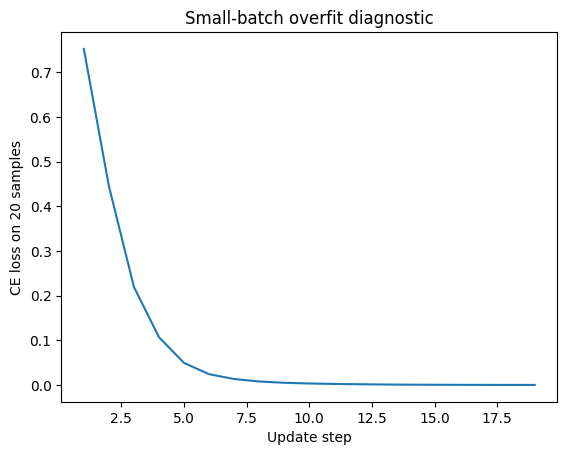

In [17]:
# Isolated 20-sample diagnostic; no validation or eval samples enter this training.
set_seed(1)
overfit_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
indices = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(42))[:20].to(device)
small_x, small_y = data["X_tr"][indices], data["y_tr"][indices]
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=0.01)
overfit_losses = []
for step in range(300):
    overfit_model.train()
    overfit_optimizer.zero_grad(set_to_none=True)
    loss = F.cross_entropy(overfit_model(small_x), small_y)
    loss.backward()
    overfit_optimizer.step()
    overfit_model.eval()
    with torch.no_grad():
        current_logits = overfit_model(small_x)
        current_loss = F.cross_entropy(current_logits, small_y).item()
        current_acc = (current_logits.argmax(1) == small_y).float().mean().item()
    overfit_losses.append(current_loss)
    if step % 25 == 0 or (current_acc == 1.0 and current_loss < 1e-4):
        print(f"step {step + 1}: loss={current_loss:.6g}, acc={current_acc:.3f}")
    if current_acc == 1.0 and current_loss < 1e-4:
        break
plt.plot(range(1, len(overfit_losses) + 1), overfit_losses)
plt.xlabel("Update step"); plt.ylabel("CE loss on 20 samples")
plt.title("Small-batch overfit diagnostic"); plt.show()


**Small-batch observation (fill after running):** Final loss: ___. Final accuracy: ___. Did loss decrease toward zero and accuracy reach or approach 100%? If not, inspect labels, logits, gradients, and the update step before longer training.


## Part 2 ? Baseline

`DEFAULT_CFG` fixes M-base `(256,128)`, He, CE, SGD momentum 0.9, batch 512, 20 epochs, zero dropout, no clipping, and FP32. Its learning rate stays unset until selected from validation. `run_and_save` calls the shared training pipeline and saves JSON and PNG; `best_state` remains in memory because JSON intentionally excludes weights.


In [18]:
RUN_RESULTS = {}
def run_and_save(cfg, data):
    if cfg["lr"] is None:
        raise ValueError("Choose cfg['lr'] using validation before running")
    result = run_experiment(cfg, data)
    save_result(result, str(RESULTS_DIR))
    plot_run(result, str(FIGURES_DIR / f"{cfg['exp_id']}.png"))
    RUN_RESULTS[cfg["exp_id"]] = result
    print(cfg["exp_id"], result["summary"])
    return result


### Baseline learning-rate search

The three candidates share the same 5-epoch pilot budget and seed. Enable the cell to run them. Inspect their validation curves and metrics, then explicitly choose the official baseline LR below. Pilot results are separate from 20-epoch official baseline runs.


In [19]:
RUN_LR_SEARCH = True
LR_SEARCH_EPOCHS = 5
lr_search_cfgs = [
    {**DEFAULT_CFG, "exp_id": f"lr-sgdm-{lr:g}", "group": "lr_search",
     "description": f"SGD momentum LR pilot {lr:g}", "lr": lr,
     "epochs": LR_SEARCH_EPOCHS, "seed": 1}
    for lr in (0.01, 0.03, 0.1)
]
if RUN_LR_SEARCH:
    lr_search_results = [run_and_save(candidate, data) for candidate in lr_search_cfgs]
    for result in lr_search_results:
        summary = result["summary"]
        print(result["cfg"]["lr"], summary["best_val_loss"],
              summary["val_macro_f1"], summary["diverged"])


lr-sgdm-0.01 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.44888190709975995, 'best_epoch': 5, 'final_train_loss': 0.4443880217075348, 'final_val_loss': 0.44888190709975995, 'val_acc': 0.8122566209849186, 'val_macro_f1': 0.6261098502009574, 'time_per_epoch_s': 1.3345572513999742, 'peak_mem_MB': 164.24853515625, 'diverged': False}
lr-sgdm-0.03 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.38941404517804207, 'best_epoch': 5, 'final_train_loss': 0.3853182848072052, 'final_val_loss': 0.38941404517804207, 'val_acc': 0.8366214152019105, 'val_macro_f1': 0.6945203316800398, 'time_per_epoch_s': 1.3317892358000791, 'peak_mem_MB': 164.24853515625, 'diverged': False}
lr-sgdm-0.1 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.34000839112032244, 'best_epoch': 5, 'final_train_loss': 0.3321183898353577, 'final_val_loss': 0.34000839112032244, 'val_acc': 0.8572965297648502, 'val_macro_f1': 0.7725161976722414, 'time_per_epoch_s': 1.2857878232000075, 'peak_mem_MB': 164.24853515625, 'diverged

**LR decision (fill after pilots):** Set `BASELINE_LR` using validation loss, macro-F1, stability, and curves. Record why it was chosen. Do not consult eval.


In [26]:
BASELINE_LR = 0.1  # Replace with the validation-chosen LR, e.g. one tested above.
base_cfg = {**DEFAULT_CFG, "lr": BASELINE_LR}


### Official baseline seeds

Enable after setting `BASELINE_LR`. Seeds 1 and 2 are prepared; add seed 3 if useful. Each run is 20 epochs and gets its own JSON and three-panel plot.


In [27]:
RUN_BASELINE_SEEDS = True
BASELINE_SEEDS = (1, 2)  # Optionally use (1, 2, 3).
if RUN_BASELINE_SEEDS:
    if BASELINE_LR is None:
        raise ValueError("Set BASELINE_LR from validation before official baseline runs")
    baseline_runs = [
        run_and_save({**base_cfg, "seed": seed, "exp_id": f"base-s{seed}",
                      "description": f"Baseline M-base, seed {seed}"}, data)
        for seed in BASELINE_SEEDS
    ]


base-s1 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.3008295753499624, 'peak_mem_MB': 164.24853515625, 'diverged': False}
base-s2 {'step0_loss': 1.9781567119120453, 'best_val_loss': 0.22674971043362127, 'best_epoch': 19, 'final_train_loss': 0.2048543677330017, 'final_val_loss': 0.2268821674556105, 'val_acc': 0.9089412878380414, 'val_macro_f1': 0.851843856248737, 'time_per_epoch_s': 1.3147939769999766, 'peak_mem_MB': 164.24853515625, 'diverged': False}


In [28]:
baseline_saved = [r for r in load_results(str(RESULTS_DIR))
                  if r["cfg"]["group"] == "baseline"]
if baseline_saved:
    for key in ("val_macro_f1", "val_acc", "best_val_loss"):
        values = np.array([r["summary"][key] for r in baseline_saved], dtype=float)
        if len(values) > 1:
            print(key, "mean:", values.mean(), "std:", values.std(ddof=1))
        else:
            print(key, "one seed only; seed noise cannot be estimated")
else:
    print("No official baseline results saved yet")


val_macro_f1 mean: 0.8565809005979659 std: 0.00669919236424233
val_acc mean: 0.9096404982681096 std: 0.000988832873155107
best_val_loss mean: 0.22700421284639047 std: 0.00035992076379487463


**Baseline observation (fill after running):** Describe train/validation curves, best epoch, validation accuracy relative to the majority-class reference, and seed mean ? standard deviation. If only one seed ran, record that uncertainty.


## Part 3 ? Experiments

For each topic, write a prediction **before** enabling its execution cell. Keep the split, seed, epochs, and all unrelated settings fixed. Results below are configuration menus, not completed experiments. Set only the topic flag you want to run. Every executed configuration passes through `run_and_save`.


### 1. Loss

**Prediction before running:** ___

Compare CE with one-hot MSE using validation accuracy, macro-F1, and convergence. Raw CE and MSE losses have different scales and should not be compared directly.


In [32]:
loss_cfgs = [
    {**base_cfg, "exp_id": "loss-ce", "group": "loss", "description": "CE reference", "loss": "ce"},
    {**base_cfg, "exp_id": "loss-mse", "group": "loss", "description": "One-hot MSE", "loss": "mse"},
]


In [33]:
RUN_LOSS = True
if RUN_LOSS:
    loss_runs = [run_and_save(candidate, data) for candidate in loss_cfgs]


loss-ce {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.2978149342000278, 'peak_mem_MB': 164.24853515625, 'diverged': False}
loss-mse {'step0_loss': 0.6358503537817057, 'best_val_loss': 0.029242694497958653, 'best_epoch': 20, 'final_train_loss': 0.02838931271970272, 'final_val_loss': 0.029242694497958653, 'val_acc': 0.8719907058798219, 'val_macro_f1': 0.7322342088404575, 'time_per_epoch_s': 1.3695906523499617, 'peak_mem_MB': 164.251953125, 'diverged': False}


**Observation after running:** ___  Which validation metrics and curve shapes changed? Did this match the prediction?


### 2. Optimizer

**Prediction before running:** ___

Each optimizer receives three LR candidates. Weight decay remains zero so the primary changed factor is the optimizer; Adam and AdamW can coincide when weight decay is zero. Compare each optimizer after its own LR search on validation.


In [29]:
optimizer_lrs = {
    "sgd_momentum": (0.01, 0.03, 0.1),
    "adam": (3e-4, 1e-3, 3e-3),
    "adamw": (3e-4, 1e-3, 3e-3),
}
optimizer_cfgs = [
    {**base_cfg, "exp_id": f"opt-{name}-{lr:g}", "group": "optimizer",
     "description": f"{name} LR {lr:g}", "optimizer": name, "lr": lr,
     "weight_decay": 0.0}
    for name, candidates in optimizer_lrs.items() for lr in candidates
]


In [30]:
RUN_OPTIMIZER = True
if RUN_OPTIMIZER:
    optimizer_runs = [run_and_save(candidate, data) for candidate in optimizer_cfgs]


opt-sgd_momentum-0.01 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.3174855356982657, 'best_epoch': 19, 'final_train_loss': 0.3174545863056183, 'final_val_loss': 0.32795201186156026, 'val_acc': 0.8711408962802005, 'val_macro_f1': 0.7653364267752982, 'time_per_epoch_s': 1.3007332999000938, 'peak_mem_MB': 164.24853515625, 'diverged': False}
opt-sgd_momentum-0.03 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.266836969337099, 'best_epoch': 17, 'final_train_loss': 0.24860776794433595, 'final_val_loss': 0.26687376323776973, 'val_acc': 0.8925582496073664, 'val_macro_f1': 0.8214142514825234, 'time_per_epoch_s': 1.296659743249893, 'peak_mem_MB': 164.24853515625, 'diverged': False}
opt-sgd_momentum-0.1 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.3458353278000232, 'peak_mem_MB'

In [31]:
from collections import defaultdict
optimizer_saved = [r for r in load_results(str(RESULTS_DIR))
                   if r["cfg"]["group"] == "optimizer" and not r["summary"]["diverged"]]
by_optimizer = defaultdict(list)
for result in optimizer_saved:
    by_optimizer[result["cfg"]["optimizer"]].append(result)
for name, candidates in sorted(by_optimizer.items()):
    best = max(candidates, key=lambda r: r["summary"]["val_macro_f1"])
    print(name, "best tested validation candidate:", best["cfg"]["exp_id"],
          "lr:", best["cfg"]["lr"], "val macro-F1:", best["summary"]["val_macro_f1"])


adam best tested validation candidate: opt-adam-0.003 lr: 0.003 val macro-F1: 0.8760285836352688
adamw best tested validation candidate: opt-adamw-0.003 lr: 0.003 val macro-F1: 0.8760285836352688
sgd_momentum best tested validation candidate: opt-sgd_momentum-0.1 lr: 0.1 val macro-F1: 0.8613179449471948


**Observation after running:** ___  Compare each optimizer at its best tested validation LR, then consider seed noise and curve stability before drawing a conclusion.


### 3. Hyperparameter ? batch size

**Prediction before running:** ___

Change batch size only: 128, 512, 2048. Same epoch count gives different numbers of optimizer updates; account for that and epoch time in the interpretation.


In [34]:
hparam_cfgs = [
    {**base_cfg, "exp_id": f"batch-{batch}", "group": "hparam",
     "description": f"Batch size {batch}", "batch": batch}
    for batch in (128, 512, 2048)
]


In [35]:
RUN_HPARAM = True
if RUN_HPARAM:
    hparam_runs = [run_and_save(candidate, data) for candidate in hparam_cfgs]


batch-128 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22508606545224621, 'best_epoch': 20, 'final_train_loss': 0.1958975608444214, 'final_val_loss': 0.22508606545224621, 'val_acc': 0.9123512833200662, 'val_macro_f1': 0.8589141080416443, 'time_per_epoch_s': 5.112511323199987, 'peak_mem_MB': 164.22119140625, 'diverged': False}
batch-512 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.2945996225999807, 'peak_mem_MB': 164.24853515625, 'diverged': False}
batch-2048 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.2798479185457579, 'best_epoch': 20, 'final_train_loss': 0.2638189685535431, 'final_val_loss': 0.2798479185457579, 'val_acc': 0.8853402465523548, 'val_macro_f1': 0.8116013155412866, 'time_per_epoch_s': 0.3414932665000606, 'peak_mem_MB': 164.46728515625, 'diverged': Fal

**Observation after running:** ___  Include validation metrics, update counts, and time per epoch.


### 4. Dropout

**Prediction before running:** ___

Test 0.0, 0.3, 0.5 after inspecting baseline train/validation curves. Dropout is most meaningful when baseline shows overfitting.


In [36]:
dropout_cfgs = [
    {**base_cfg, "exp_id": f"drop-{rate:g}", "group": "dropout",
     "description": f"Dropout {rate:g}", "dropout": rate}
    for rate in (0.0, 0.3, 0.5)
]


In [37]:
RUN_DROPOUT = True
if RUN_DROPOUT:
    dropout_runs = [run_and_save(candidate, data) for candidate in dropout_cfgs]


drop-0 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.307640775200025, 'peak_mem_MB': 164.24853515625, 'diverged': False}
drop-0.3 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.3209363218114866, 'best_epoch': 18, 'final_train_loss': 0.3164951332473755, 'final_val_loss': 0.32101994226802166, 'val_acc': 0.8691831070760095, 'val_macro_f1': 0.7750977068629922, 'time_per_epoch_s': 1.4169615780999947, 'peak_mem_MB': 164.24853515625, 'diverged': False}
drop-0.5 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.40537158257143496, 'best_epoch': 17, 'final_train_loss': 0.4021722459125519, 'final_val_loss': 0.4060506547218792, 'val_acc': 0.8276930358641165, 'val_macro_f1': 0.6751845403429256, 'time_per_epoch_s': 1.4528977266499397, 'peak_mem_MB': 164.24853515625, 'diverged': False}


**Observation after running:** ___  Did the train/validation gap indicate overfitting, and did dropout change validation metrics?


### 5. Gradient clipping

**Prediction before running:** ___

First inspect the baseline's recorded average global gradient norm before clipping. Choose a high LR and `CLIP_NORM` from observed gradients; no threshold is presumed correct. The paired high-LR runs differ only in clipping.


In [38]:
baseline_reference = next((r for r in load_results(str(RESULTS_DIR))
                           if r["cfg"]["exp_id"] == "base-s1"), None)
if baseline_reference is None:
    print("Run baseline seed 1 before choosing a clipping threshold")
else:
    print("Baseline average pre-clip grad norm by epoch:",
          baseline_reference["history"]["grad_norm"])


Baseline average pre-clip grad norm by epoch: [0.5294402720921633, 0.5659280539460818, 0.5923259950241656, 0.5888231818088967, 0.5828978393477947, 0.5964452535774881, 0.5772051123346227, 0.5733325619563112, 0.5813167751491316, 0.5745757258249936, 0.5762514270729343, 0.5770580187706377, 0.5791070633856106, 0.5699519206765922, 0.5702703847271868, 0.5667129104042316, 0.5588723909330171, 0.5655048540812575, 0.5644569768374363, 0.5522769673982382]


In [39]:
HIGH_LR = 1.0  # Choose from validation/pilot behavior.
CLIP_NORM = 0.5  # Choose after inspecting baseline gradient norms.
clip_cfgs = []
if HIGH_LR is not None and CLIP_NORM is not None:
    clip_cfgs = [
        {**base_cfg, "exp_id": "clip-highlr-none", "group": "clipping",
         "description": "High LR without clipping", "lr": HIGH_LR, "clip_norm": None},
        {**base_cfg, "exp_id": f"clip-highlr-{CLIP_NORM:g}", "group": "clipping",
         "description": f"High LR with clip {CLIP_NORM:g}", "lr": HIGH_LR,
         "clip_norm": CLIP_NORM},
    ]


In [40]:
RUN_CLIPPING = True
if RUN_CLIPPING:
    if not clip_cfgs:
        raise ValueError("Set HIGH_LR and CLIP_NORM from observed validation/gradients")
    clipping_runs = [run_and_save(candidate, data) for candidate in clip_cfgs]


clip-highlr-none {'step0_loss': 2.2690618110553, 'best_val_loss': 0.3874509567745694, 'best_epoch': 19, 'final_train_loss': 0.37438961565971374, 'final_val_loss': 0.3885752201639424, 'val_acc': 0.841203932789742, 'val_macro_f1': 0.5977439770384045, 'time_per_epoch_s': 1.3209344381500159, 'peak_mem_MB': 164.24853515625, 'diverged': False}
clip-highlr-0.5 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.30184140313561864, 'best_epoch': 15, 'final_train_loss': 0.29677437346458435, 'final_val_loss': 0.3223491121324819, 'val_acc': 0.8847593640412211, 'val_macro_f1': 0.8093139400808786, 'time_per_epoch_s': 1.3205571675998726, 'peak_mem_MB': 164.24853515625, 'diverged': False}


**Observation after running:** ___  Was clipping active at this threshold? Compare divergence, gradients, and validation metrics for the matched high-LR pair.


### 6. Mixed precision

**Prediction before running:** ___

Compare FP32 and FP16 on CUDA; add BF16 only when `torch.cuda.is_bf16_supported()` returns true. Compare validation metrics, time per epoch, and peak allocated GPU memory. Precision is not expected to improve accuracy by itself.


In [41]:
amp_modes = ["fp32"]
if device.type == "cuda":
    amp_modes.append("fp16")
    if torch.cuda.is_bf16_supported():
        amp_modes.append("bf16")
amp_cfgs = [
    {**base_cfg, "exp_id": f"amp-{precision}", "group": "amp",
     "description": f"Precision {precision}", "precision": precision}
    for precision in amp_modes
]
print("Supported comparison modes:", amp_modes)


Supported comparison modes: ['fp32', 'fp16', 'bf16']


In [42]:
RUN_AMP = True
if RUN_AMP:
    if device.type != "cuda":
        raise RuntimeError("Select a CUDA runtime for the mixed-precision comparison")
    amp_runs = [run_and_save(candidate, data) for candidate in amp_cfgs]
    for result in amp_runs:
        s = result["summary"]
        print(result["cfg"]["precision"], "val macro-F1:", s["val_macro_f1"],
              "seconds/epoch:", s["time_per_epoch_s"], "peak MB:", s["peak_mem_MB"])


amp-fp32 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.3179123606999383, 'peak_mem_MB': 164.24853515625, 'diverged': False}
amp-fp16 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.28939940539528886, 'best_epoch': 8, 'final_train_loss': 0.27848958847045896, 'final_val_loss': 0.28939940539528886, 'val_acc': 0.8807469718809836, 'val_macro_f1': 0.8246330272210439, 'time_per_epoch_s': 1.751820993750016, 'peak_mem_MB': 164.24951171875, 'diverged': True}
amp-bf16 {'step0_loss': 2.2690618110553, 'best_val_loss': 0.23105270067660535, 'best_epoch': 20, 'final_train_loss': 0.20627427502155304, 'final_val_loss': 0.23105270067660535, 'val_acc': 0.9085002474129215, 'val_macro_f1': 0.8547247844345146, 'time_per_epoch_s': 1.5327374787501413, 'peak_mem_MB': 164.24853515625, 'diverged': False

**Observation after running:** ___  Explain speed, memory, and stability differences, including a lack of speedup if observed.


### 7. Initialization

**Prediction before running:** ___

Compare He, Xavier, small normal, and PyTorch default with all other configuration fields fixed. Optionally enable zero initialization as a symmetry diagnostic, not as a competitive configuration. Inspect activation standard deviations on a fixed validation batch before training.


In [46]:
INCLUDE_ZEROS_DIAGNOSTIC = True
init_modes = ["he", "xavier", "normal", "default"]
if INCLUDE_ZEROS_DIAGNOSTIC:
    init_modes.append("zeros")
init_cfgs = [
    {**base_cfg, "exp_id": f"init-{mode}", "group": "init",
     "description": f"Initialization {mode}", "init": mode}
    for mode in init_modes
]
fixed_val_x = data["X_val"][:512]
for mode in init_modes:
    set_seed(base_cfg["seed"])
    probe = MLP(hidden=base_cfg["hidden"], dropout=0.0, init=mode).to(device)
    print(mode, "activation std after each Linear:", activation_stats(probe, fixed_val_x))


he activation std after each Linear: [0.6662027835845947, 0.646382212638855, 0.5932615399360657]
xavier activation std after each Linear: [0.2780497372150421, 0.2202722579240799, 0.196858748793602]
normal activation std after each Linear: [0.03461690992116928, 0.0037999360356479883, 0.0002790121070574969]
default activation std after each Linear: [0.2753431797027588, 0.11358198523521423, 0.059335775673389435]
zeros activation std after each Linear: [0.0, 0.0, 0.0]


In [47]:
RUN_INIT = True
if RUN_INIT:
    init_runs = [run_and_save(candidate, data) for candidate in init_cfgs]


init-he {'step0_loss': 2.2690618110553, 'best_val_loss': 0.22725871525915967, 'best_epoch': 20, 'final_train_loss': 0.20299741819381714, 'final_val_loss': 0.22725871525915967, 'val_acc': 0.9103397086981777, 'val_macro_f1': 0.8613179449471948, 'time_per_epoch_s': 1.3256072093000058, 'peak_mem_MB': 164.431640625, 'diverged': False}
init-xavier {'step0_loss': 2.0221761869652255, 'best_val_loss': 0.2282389023751729, 'best_epoch': 20, 'final_train_loss': 0.2046419521665573, 'final_val_loss': 0.2282389023751729, 'val_acc': 0.9079516361524064, 'val_macro_f1': 0.8582325572332149, 'time_per_epoch_s': 1.284443464449987, 'peak_mem_MB': 164.431640625, 'diverged': False}
init-normal {'step0_loss': 1.9459956574185073, 'best_val_loss': 0.2476156445638117, 'best_epoch': 19, 'final_train_loss': 0.24233512052059172, 'final_val_loss': 0.26508922543601815, 'val_acc': 0.900550762677223, 'val_macro_f1': 0.840995046957501, 'time_per_epoch_s': 1.294966028099998, 'peak_mem_MB': 164.431640625, 'diverged': False

**Observation after running:** ___  Relate measured activation scales and validation curves to the initialization mechanism. If zeros were run, discuss symmetry.


### Compare saved validation results

Saved JSON has configuration, history, and summary but no model weights. Filter by `group`, inspect validation scores and stability, and generate group comparison figures when requested. Do not use eval here.


In [48]:
saved_results = load_results(str(RESULTS_DIR))
for group in sorted({r["cfg"]["group"] for r in saved_results}):
    print("GROUP", group)
    for result in (r for r in saved_results if r["cfg"]["group"] == group):
        cfg, s = result["cfg"], result["summary"]
        print(cfg["exp_id"], "val F1:", s["val_macro_f1"],
              "val loss:", s["best_val_loss"], "diverged:", s["diverged"])


GROUP amp
amp-bf16 val F1: 0.8547247844345146 val loss: 0.23105270067660535 diverged: False
amp-fp16 val F1: 0.8246330272210439 val loss: 0.28939940539528886 diverged: True
amp-fp32 val F1: 0.8613179449471948 val loss: 0.22725871525915967 diverged: False
GROUP baseline
base-s1 val F1: 0.8613179449471948 val loss: 0.22725871525915967 diverged: False
base-s2 val F1: 0.851843856248737 val loss: 0.22674971043362127 diverged: False
GROUP clipping
clip-highlr-0.5 val F1: 0.8093139400808786 val loss: 0.30184140313561864 diverged: False
clip-highlr-none val F1: 0.5977439770384045 val loss: 0.3874509567745694 diverged: False
GROUP dropout
drop-0 val F1: 0.8613179449471948 val loss: 0.22725871525915967 diverged: False
drop-0.3 val F1: 0.7750977068629922 val loss: 0.3209363218114866 diverged: False
drop-0.5 val F1: 0.6751845403429256 val loss: 0.40537158257143496 diverged: False
GROUP hparam
batch-128 val F1: 0.8589141080416443 val loss: 0.22508606545224621 diverged: False
batch-2048 val F1: 0.81

In [49]:
RUN_COMPARISON_PLOTS = True
COMPARE_GROUP = "optimizer"
COMPARE_METRIC = "val_macro_f1"
if RUN_COMPARISON_PLOTS:
    selected = [r for r in load_results(str(RESULTS_DIR))
                if r["cfg"]["group"] == COMPARE_GROUP]
    if len(selected) < 2:
        raise ValueError(f"Need at least two saved results in group {COMPARE_GROUP!r}")
    plot_compare(selected, COMPARE_METRIC,
                 str(FIGURES_DIR / f"compare_{COMPARE_GROUP}.png"),
                 title=f"{COMPARE_GROUP}: {COMPARE_METRIC}")


## Part 4 ? Final Selection and Evaluation

### Select final configuration using validation only

Review validation macro-F1, validation loss, baseline seed noise, divergence, and training cost. The table below uses saved validation results only. Explicitly define `FINAL_CFG` after review; no code selects a winner automatically.


In [50]:
for result in load_results(str(RESULTS_DIR)):
    cfg, s = result["cfg"], result["summary"]
    print(cfg["exp_id"], "val macro-F1:", s["val_macro_f1"],
          "best val loss:", s["best_val_loss"],
          "seconds/epoch:", s["time_per_epoch_s"],
          "peak MB:", s["peak_mem_MB"], "diverged:", s["diverged"])


amp-bf16 val macro-F1: 0.8547247844345146 best val loss: 0.23105270067660535 seconds/epoch: 1.5327374787501413 peak MB: 164.24853515625 diverged: False
amp-fp16 val macro-F1: 0.8246330272210439 best val loss: 0.28939940539528886 seconds/epoch: 1.751820993750016 peak MB: 164.24951171875 diverged: True
amp-fp32 val macro-F1: 0.8613179449471948 best val loss: 0.22725871525915967 seconds/epoch: 1.3179123606999383 peak MB: 164.24853515625 diverged: False
base-s1 val macro-F1: 0.8613179449471948 best val loss: 0.22725871525915967 seconds/epoch: 1.3008295753499624 peak MB: 164.24853515625 diverged: False
base-s2 val macro-F1: 0.851843856248737 best val loss: 0.22674971043362127 seconds/epoch: 1.3147939769999766 peak MB: 164.24853515625 diverged: False
batch-128 val macro-F1: 0.8589141080416443 best val loss: 0.22508606545224621 seconds/epoch: 5.112511323199987 peak MB: 164.22119140625 diverged: False
batch-2048 val macro-F1: 0.8116013155412866 best val loss: 0.2798479185457579 seconds/epoch: 

In [54]:
FINAL_CFG = dict(RUN_RESULTS["opt-adam-0.003"]["cfg"])
print(FINAL_CFG)

{'exp_id': 'opt-adam-0.003', 'group': 'optimizer', 'description': 'adam LR 0.003', 'loss': 'ce', 'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 512, 'epochs': 20, 'hidden': (256, 128), 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}


`save_result` does not store `best_state`. If the chosen run is still in `RUN_RESULTS`, use its in-memory best weights. After a Colab restart, explicitly set `RERUN_FINAL_IF_NEEDED=True` to rerun that configuration before prediction. Only enable final evaluation after the validation decision is recorded.


In [55]:
RUN_FINAL_EVAL = True
RERUN_FINAL_IF_NEEDED = False
PREDICTIONS_PATH = OUT_DIR / "predictions_eval.csv"
EVAL_RESULT_PATH = OUT_DIR / "eval_result.json"
if RUN_FINAL_EVAL:
    if FINAL_CFG is None:
        raise ValueError("Define FINAL_CFG using validation before final evaluation")
    chosen_result = RUN_RESULTS.get(FINAL_CFG["exp_id"])
    if chosen_result is None and RERUN_FINAL_IF_NEEDED:
        chosen_result = run_and_save(FINAL_CFG, data)
    if chosen_result is None:
        raise RuntimeError("Best weights are not in memory; rerun explicitly")
    if chosen_result["cfg"] != FINAL_CFG:
        raise ValueError("FINAL_CFG differs from the in-memory trained configuration")
    final_eval(FINAL_CFG, chosen_result, data, str(PREDICTIONS_PATH))
    print("Predictions written:", PREDICTIONS_PATH)


Predictions written: /content/K4-Track4-Day1-Neuralnetwork/predictions_eval.csv


### Separate final scoring command

Run only after `predictions_eval.csv` exists. The shell equivalent is `python scripts/evaluate.py --pred <predictions_eval.csv> --out <eval_result.json>`. This score is for reporting; **after viewing eval results, do not retune the configuration using eval**.


In [56]:
RUN_EVAL_SCORER = True
if RUN_EVAL_SCORER:
    if not PREDICTIONS_PATH.is_file():
        raise FileNotFoundError(PREDICTIONS_PATH)
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts" / "evaluate.py"),
                    "--pred", str(PREDICTIONS_PATH),
                    "--out", str(EVAL_RESULT_PATH)],
                   cwd=REPO_ROOT, check=True)


In [57]:
print(EVAL_RESULT_PATH.read_text(encoding="utf-8"))

{
  "n_eval": 116203,
  "accuracy": 0.9157767011178714,
  "macro_f1": 0.8793854637439035,
  "per_class": [
    {
      "cls": 0,
      "support": 42368,
      "precision": 0.9149696320114327,
      "recall": 0.9066984516616314,
      "f1": 0.9108152644245019
    },
    {
      "cls": 1,
      "support": 56661,
      "precision": 0.9224019120392177,
      "recall": 0.9331462558020508,
      "f1": 0.9277429769612745
    },
    {
      "cls": 2,
      "support": 7151,
      "precision": 0.9103563474387528,
      "recall": 0.914557404558803,
      "f1": 0.9124520404604116
    },
    {
      "cls": 3,
      "support": 549,
      "precision": 0.87,
      "recall": 0.7923497267759563,
      "f1": 0.8293612964728313
    },
    {
      "cls": 4,
      "support": 1899,
      "precision": 0.8315553060078608,
      "recall": 0.779884149552396,
      "f1": 0.8048913043478261
    },
    {
      "cls": 5,
      "support": 3473,
      "precision": 0.8535788535788535,
      "recall": 0.8275266340339764

**Final eval observation (fill only after scoring):** Record accuracy, macro-F1, per-class F1, and confusion-matrix patterns from the real `eval_result.json`. Identify the hardest class and a likely source of confusion. No new configuration selection is allowed here.


### Create `experiments.xlsx` from real saved results

The template's `Legend`, `Experiments`, `Seeds`, and `Summary` sheets remain intact. `write_xlsx` fills the `Experiments` sheet by header and preserves formula cells. Only attach eval scores from an actual scorer JSON, and only to the matching final run. If you also score the baseline, add its real score separately. Fill `Seeds` and write short `Summary` observations in Excel after the workbook is created.


In [58]:
RUN_XLSX = True
BASELINE_EVAL_JSON = None  # Optional path to a real baseline scorer JSON.
if RUN_XLSX:
    if importlib.util.find_spec("openpyxl") is None:
        raise ImportError("openpyxl is required to write experiments.xlsx")
    scored = {}
    if EVAL_RESULT_PATH.is_file():
        if FINAL_CFG is None:
            raise ValueError("Set FINAL_CFG before attributing final eval scores")
        scored[FINAL_CFG["exp_id"]] = json.loads(EVAL_RESULT_PATH.read_text(encoding="utf-8"))
    if BASELINE_EVAL_JSON is not None:
        scored["base-s1"] = json.loads(Path(BASELINE_EVAL_JSON).read_text(encoding="utf-8"))
    saved = load_results(str(RESULTS_DIR))
    if not saved:
        raise ValueError("No saved results to add to experiments.xlsx")
    absent_figures = [r["cfg"]["exp_id"] for r in saved
                      if not (FIGURES_DIR / f"{r['cfg']['exp_id']}.png").is_file()]
    if absent_figures:
        raise FileNotFoundError(f"Missing run figures: {absent_figures}")
    rows = [to_row(r, eval_scores=scored.get(r["cfg"]["exp_id"])) for r in saved]
    template = REPO_ROOT / "templates" / "experiment_table_template.xlsx"
    table_path = OUT_DIR / "experiments.xlsx"
    write_xlsx(rows, str(template), str(table_path))
    print("Workbook written:", table_path)


Workbook written: /content/K4-Track4-Day1-Neuralnetwork/experiments.xlsx


### Report and submission checklist

Set `STUDENT_ID` below; do not guess it. Prepare `submission_STUDENT_ID/` with `REPORT.md`, `experiments.xlsx`, `predictions_eval.csv`, `eval_result.json`, `figures/`, `results/`, and `code/` (including this notebook and the six modules). When running from `submission_STUDENT_ID/code/`, outputs already go to the submission folder. When running from repository `code/`, copy the finished outputs and code into the submission folder yourself; this notebook does not create it.

Start `REPORT.md` from `templates/REPORT_TEMPLATE.md`. Fill in the setup and data split, model and step-0/small-batch checks, baseline seed noise, and **only** the experiment topics actually run. Each topic needs its pre-run prediction, measured values linked to `exp_id` and figure, mechanism, and comparison against seed noise. Explain final selection from validation; then report real eval metrics, per-class F1, and confusion-matrix errors. Answer: **If loss does not decrease, what should be checked first?** Include limitations and unexpected outcomes. Every numerical claim must trace to a saved result or scorer output. Keep notebook outputs when saving.


In [59]:
STUDENT_ID = "2A202602954"
SUBMISSION_DIR = REPO_ROOT / f"submission_{STUDENT_ID}"
print("Expected submission directory:", SUBMISSION_DIR)
print("Current output directory:", OUT_DIR)


Expected submission directory: /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602954
Current output directory: /content/K4-Track4-Day1-Neuralnetwork
